# Phase 1: Data Quality Assessment

**Objective**: Identify data recording errors and determine which fields are reliable for analysis.

> "Where you expect a number around 50-100, do you suddenly see a negative number? A 5-digit number? See if data is reasonable and logical."

This notebook examines:
1. Missing values across all columns
2. Columns and rows with highest data availability
3. Duplicate records
4. Logical inconsistencies and data entry errors
5. Distribution visualizations for key variables
6. **Comprehensive data cleaning for subsequent phases**

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Persian text display fix
import arabic_reshaper
from bidi.algorithm import get_display

def fix_persian(text):
    """Reshape Persian/Arabic text for correct display in matplotlib"""
    if pd.isna(text):
        return 'Unknown/NULL'
    reshaped = arabic_reshaper.reshape(str(text))
    return get_display(reshaped)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Define paths
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES_PATH = PROJECT_ROOT / 'notebooks' / 'outputs' / 'figures'

# Create output directories if they don't exist
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_RAW}")

Project root: /home/bahman/b/repositories/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar
Data path: /home/bahman/b/repositories/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar/data/raw


In [3]:
# Load the full dataset
DATA_FILE = DATA_RAW / 'divar_real_estate_ads.csv'
print(f"Loading data from: {DATA_FILE}")

df = pd.read_csv(DATA_FILE, low_memory=False)
print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

Loading data from: /home/bahman/b/repositories/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar/data/raw/divar_real_estate_ads.csv
Dataset loaded: 1,000,000 rows, 60 columns


## 2. Initial Data Overview

In [4]:
# Basic dataset information
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATASET OVERVIEW
Total rows: 1,000,000
Total columns: 60
Memory usage: 2603.47 MB


In [5]:
# Column names and data types
print("\nColumn names and types:")
print("-" * 60)
df.dtypes


Column names and types:
------------------------------------------------------------


cat2_slug                      object
cat3_slug                      object
city_slug                      object
neighborhood_slug              object
created_at_month               object
user_type                      object
description                    object
title                          object
rent_mode                      object
rent_value                    float64
rent_to_single                 object
rent_type                      object
price_mode                     object
price_value                   float64
credit_mode                    object
credit_value                  float64
rent_credit_transform          object
transformable_price            object
transformable_credit          float64
transformed_credit            float64
transformable_rent            float64
transformed_rent              float64
land_size                     float64
building_size                 float64
deed_type                      object
has_business_deed              object
floor       

In [6]:
# First few rows
df.head()

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_to_single,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.00,NaN,NaN,NaN,سه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,6,350000.00,1500000.00,3500000000.00,3500000.00,35.81,50.94,500.00
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,NaN,NaN,مقطوع,8500000000.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.00,NaN,NaN,3,یک,NaN,NaN,NaN,True,True,True,۱۳۸۴,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.00
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.00,NaN,NaN,NaN,NaN,مقطوع,750000000.00,False,False,750000000.00,NaN,26000000.00,NaN,NaN,132.00,NaN,NaN,3,سه,NaN,NaN,NaN,True,True,True,۱۴۰۱,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.70,51.37,NaN
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.00,NaN,NaN,NaN,NaN,مقطوع,950000000.00,False,False,950000000.00,NaN,95000000.00,NaN,NaN,90.00,NaN,NaN,4,یک,NaN,NaN,NaN,True,False,True,۱۴۰۰,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,NaN,NaN,مقطوع,5750000000.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.00,single_page,NaN,4,دو,6,NaN,true,True,True,True,۱۴۰۳,NaN,NaN,package,NaN,NaN,shoofaj,air_conditioner,squat_seat,NaN,NaN,north,NaN,NaN,NaN,ceramic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Missing Values Analysis

In [7]:
# Calculate missing values for each column
missing_stats = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum().values,
    'missing_percent': (df.isnull().sum().values / len(df) * 100),
    'non_null_count': df.notnull().sum().values,
    'dtype': df.dtypes.values
})

missing_stats = missing_stats.sort_values('missing_percent', ascending=False)
missing_stats = missing_stats.reset_index(drop=True)

print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)
missing_stats

MISSING VALUES ANALYSIS


,column,missing_count,missing_percent,non_null_count,dtype
0,rent_to_single,999981,100.00,19,object
1,cost_per_extra_person,989759,98.98,10241,float64
2,rent_price_on_special_days,989537,98.95,10463,float64
3,rent_price_at_weekends,986449,98.64,13551,float64
4,rent_price_on_regular_days,981932,98.19,18068,float64
5,extra_person_capacity,975991,97.60,24009,object
6,property_type,972943,97.29,27057,object
7,has_sauna,971521,97.15,28479,object
8,has_jacuzzi,971272,97.13,28728,object
9,has_pool,970610,97.06,29390,object


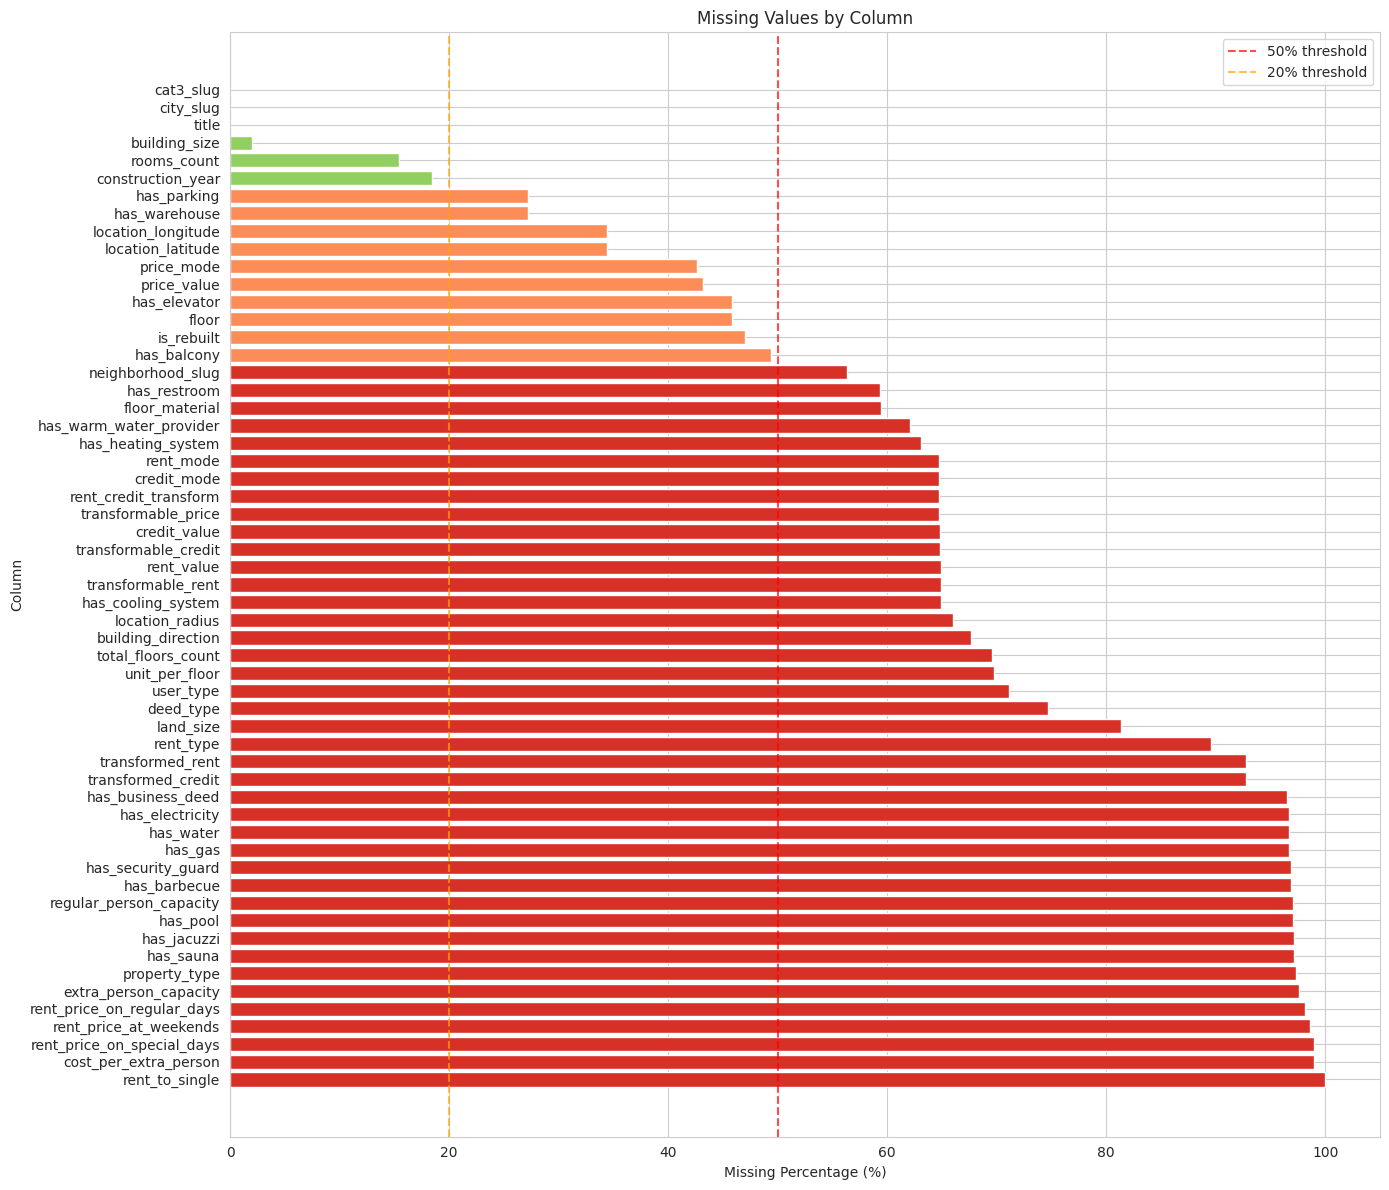

In [8]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(14, 12))

# Only show columns with some missing values for clarity
missing_cols = missing_stats[missing_stats['missing_percent'] > 0].copy()

colors = ['#d73027' if x > 50 else '#fc8d59' if x > 20 else '#91cf60' 
          for x in missing_cols['missing_percent']]

bars = ax.barh(missing_cols['column'], missing_cols['missing_percent'], color=colors)
ax.set_xlabel('Missing Percentage (%)')
ax.set_ylabel('Column')
ax.set_title('Missing Values by Column')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='20% threshold')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH / '01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

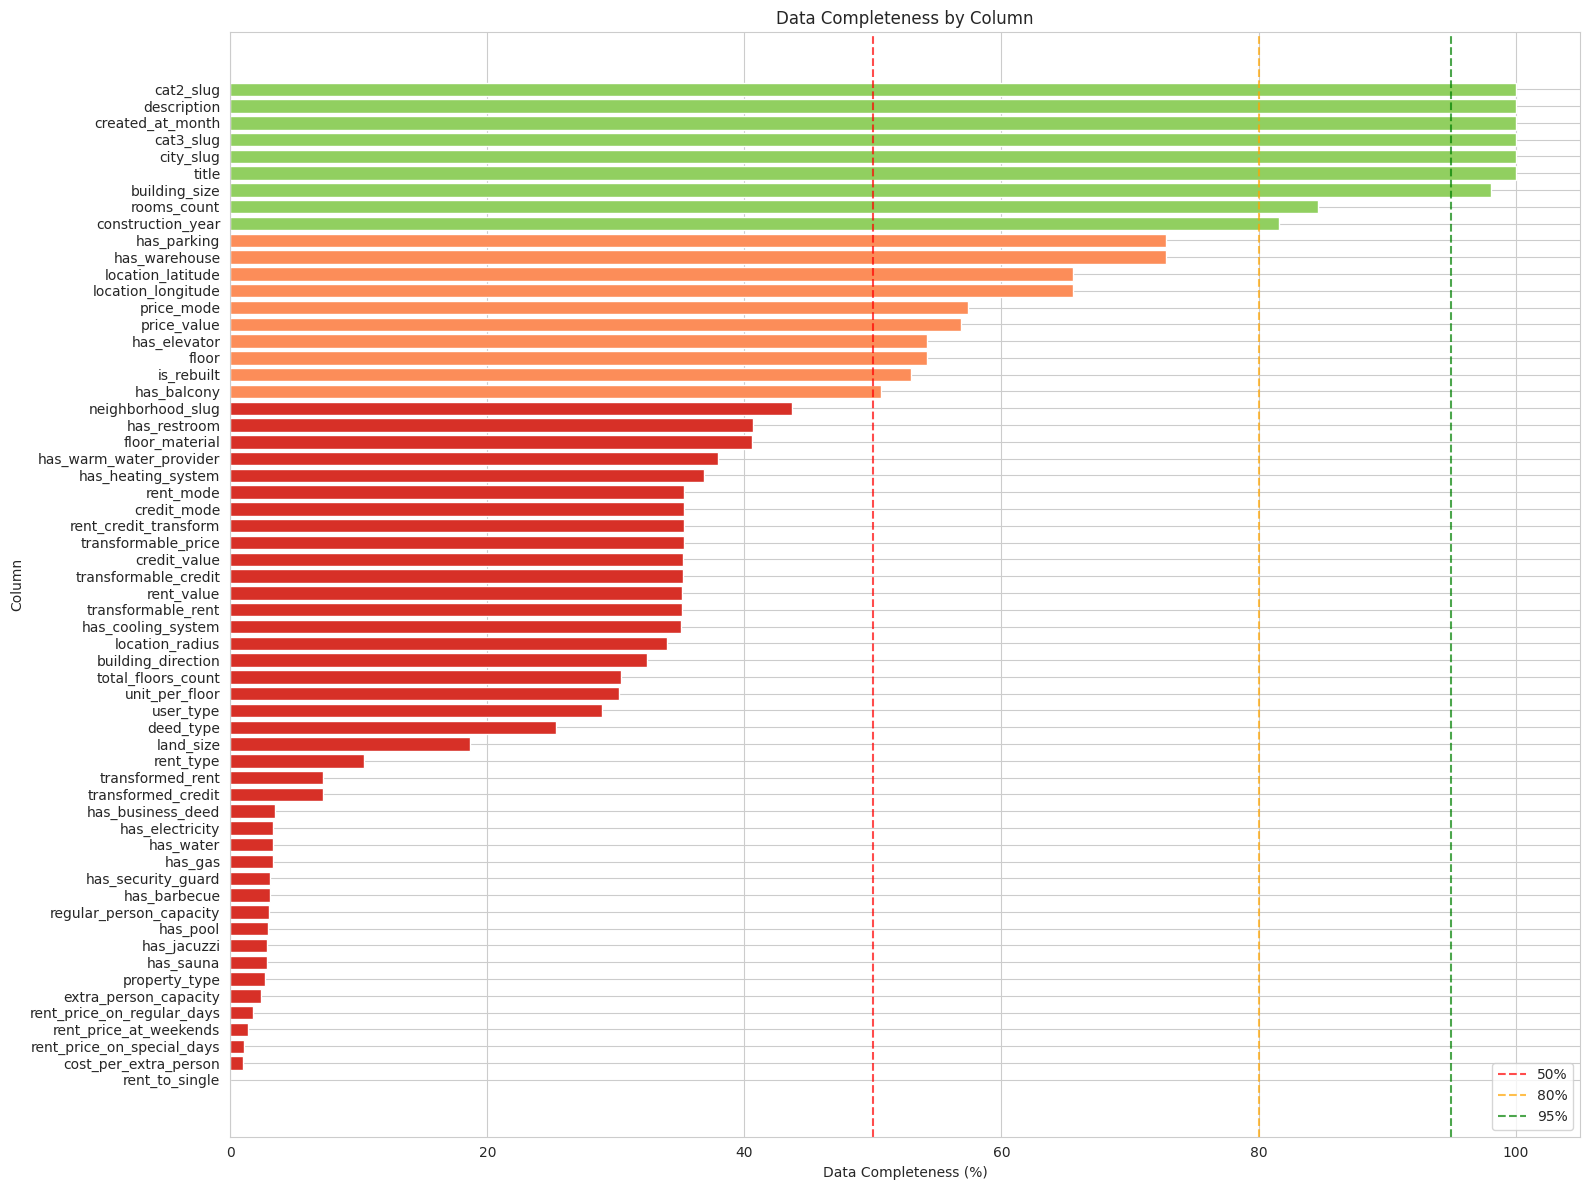

In [9]:
# Data Completeness Heatmap
fig, ax = plt.subplots(figsize=(16, 12))

# Calculate non-null percentage for each column
completeness = (df.notnull().sum() / len(df) * 100).sort_values(ascending=True)

# Create color map
colors = ['#d73027' if x < 50 else '#fc8d59' if x < 80 else '#91cf60' for x in completeness]

ax.barh(completeness.index, completeness.values, color=colors)
ax.set_xlabel('Data Completeness (%)')
ax.set_ylabel('Column')
ax.set_title('Data Completeness by Column')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50%')
ax.axvline(x=80, color='orange', linestyle='--', alpha=0.7, label='80%')
ax.axvline(x=95, color='green', linestyle='--', alpha=0.7, label='95%')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH / '01_data_completeness.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Categorize columns by data availability
high_availability = missing_stats[missing_stats['missing_percent'] <= 5]['column'].tolist()
medium_availability = missing_stats[(missing_stats['missing_percent'] > 5) & 
                                    (missing_stats['missing_percent'] <= 50)]['column'].tolist()
low_availability = missing_stats[missing_stats['missing_percent'] > 50]['column'].tolist()

print("=" * 60)
print("COLUMN CATEGORIZATION BY DATA AVAILABILITY")
print("=" * 60)

print(f"\nHIGH AVAILABILITY (<=5% missing): {len(high_availability)} columns")
print(high_availability)

print(f"\nMEDIUM AVAILABILITY (5-50% missing): {len(medium_availability)} columns")
print(medium_availability)

print(f"\nLOW AVAILABILITY (>50% missing): {len(low_availability)} columns")
print(low_availability)

COLUMN CATEGORIZATION BY DATA AVAILABILITY

HIGH AVAILABILITY (<=5% missing): 7 columns
['building_size', 'title', 'city_slug', 'cat3_slug', 'description', 'created_at_month', 'cat2_slug']

MEDIUM AVAILABILITY (5-50% missing): 12 columns
['has_balcony', 'is_rebuilt', 'floor', 'has_elevator', 'price_value', 'price_mode', 'location_latitude', 'location_longitude', 'has_warehouse', 'has_parking', 'construction_year', 'rooms_count']

LOW AVAILABILITY (>50% missing): 41 columns
['rent_to_single', 'cost_per_extra_person', 'rent_price_on_special_days', 'rent_price_at_weekends', 'rent_price_on_regular_days', 'extra_person_capacity', 'property_type', 'has_sauna', 'has_jacuzzi', 'has_pool', 'regular_person_capacity', 'has_barbecue', 'has_security_guard', 'has_gas', 'has_water', 'has_electricity', 'has_business_deed', 'transformed_credit', 'transformed_rent', 'rent_type', 'land_size', 'deed_type', 'user_type', 'unit_per_floor', 'total_floors_count', 'building_direction', 'location_radius', 'has_c

## 4. Duplicate Records Analysis

In [11]:
# Check for exact duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_percent = duplicate_count / len(df) * 100

print("=" * 60)
print("DUPLICATE RECORDS ANALYSIS")
print("=" * 60)
print(f"Exact duplicate rows: {duplicate_count:,} ({duplicate_percent:.2f}%)")

DUPLICATE RECORDS ANALYSIS
Exact duplicate rows: 0 (0.00%)


In [12]:
# Check for duplicates based on key columns (if duplicates exist)
if duplicate_count > 0:
    print("\nSample of duplicate rows:")
    duplicates = df[df.duplicated(keep=False)].sort_values(df.columns.tolist())
    print(duplicates.head(10))

In [13]:
# Check for potential duplicates based on key identifying columns
key_columns = ['title', 'price_value', 'building_size', 'city_slug']
existing_keys = [col for col in key_columns if col in df.columns]

if existing_keys:
    potential_duplicates = df.duplicated(subset=existing_keys, keep=False).sum()
    print(f"\nPotential duplicates (same {existing_keys}): {potential_duplicates:,}")


Potential duplicates (same ['title', 'price_value', 'building_size', 'city_slug']): 20,454


## 5. Value Inconsistencies and Data Entry Errors

### 5.1 Numerical Columns Analysis

In [14]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns ({len(numerical_cols)}):")
print(numerical_cols)

Numerical columns (17):
['rent_value', 'price_value', 'credit_value', 'transformable_credit', 'transformed_credit', 'transformable_rent', 'transformed_rent', 'land_size', 'building_size', 'regular_person_capacity', 'cost_per_extra_person', 'rent_price_on_regular_days', 'rent_price_on_special_days', 'rent_price_at_weekends', 'location_latitude', 'location_longitude', 'location_radius']


In [15]:
# Summary statistics for numerical columns
numerical_summary = df[numerical_cols].describe().T
numerical_summary['null_count'] = df[numerical_cols].isnull().sum()
numerical_summary['null_percent'] = numerical_summary['null_count'] / len(df) * 100
numerical_summary

,count,mean,std,min,25%,50%,75%,max,null_count,null_percent
rent_value,351322.00,41022993841.50,3807534359773.34,0.00,111111.00,5000000.00,12000000.00,999999999999999.00,648678,64.87
price_value,568346.00,17365370640.35,587873885223.63,0.00,1400000000.00,2840000000.00,5900000000.00,99999999999999.00,431654,43.17
credit_value,352095.00,48720843306.65,4341345683527.13,0.00,100000000.00,250000000.00,500000000.00,999999999999999.00,647905,64.79
transformable_credit,352085.00,48722218215.93,4341407327553.19,0.00,100000000.00,250000000.00,500000000.00,999999999999999.00,647915,64.79
transformed_credit,72409.00,8557025436.25,2064576077064.95,0.00,200000000.00,400000000.00,850000000.00,555555555555555.00,927591,92.76
transformable_rent,351248.00,41031635748.20,3807935373873.02,0.00,111111.00,5000000.00,12000000.00,999999999999999.00,648752,64.88
transformed_rent,72409.00,16199337.11,52178903.81,0.00,1000000.00,6000000.00,15000000.00,3000000000.00,927591,92.76
land_size,186396.00,4165.48,121892.69,1.00,110.00,195.00,280.00,10000000.00,813604,81.36
building_size,980394.00,4440.65,136711.84,1.00,75.00,103.00,165.00,10000000.00,19606,1.96
regular_person_capacity,29870.00,6.56,7.70,1.00,3.00,4.00,7.00,50.00,970130,97.01


In [16]:
# Check for negative values where they shouldn't exist
non_negative_columns = ['price_value', 'rent_value', 'credit_value', 
                        'building_size', 'land_size', 'rooms_count',
                        'floor', 'total_floors_count', 'unit_per_floor']

existing_non_negative = [col for col in non_negative_columns if col in df.columns]

print("=" * 60)
print("NEGATIVE VALUE CHECK")
print("=" * 60)

negative_issues = {}
for col in existing_non_negative:
    # Convert to numeric first to handle mixed types
    negative_count = (pd.to_numeric(df[col], errors='coerce') < 0).sum()
    if negative_count > 0:
        negative_issues[col] = negative_count
        print(f"{col}: {negative_count:,} negative values")

if not negative_issues:
    print("No negative values found in expected non-negative columns")

NEGATIVE VALUE CHECK
floor: 4,464 negative values


In [17]:
# Check for zero values in key columns
print("\n" + "=" * 60)
print("ZERO VALUE CHECK")
print("=" * 60)

zero_check_cols = ['price_value', 'building_size']
existing_zero_check = [col for col in zero_check_cols if col in df.columns]

for col in existing_zero_check:
    col_numeric = pd.to_numeric(df[col], errors='coerce')
    zero_count = (col_numeric == 0).sum()
    print(f"{col}: {zero_count:,} zero values ({zero_count/len(df)*100:.2f}%)")


ZERO VALUE CHECK
price_value: 1,902 zero values (0.19%)
building_size: 0 zero values (0.00%)


### 5.2 Price Analysis

In [18]:
# Price value distribution and outliers
if 'price_value' in df.columns:
    price_data = pd.to_numeric(df['price_value'], errors='coerce').dropna()
    
    print("=" * 60)
    print("PRICE VALUE ANALYSIS")
    print("=" * 60)
    print(f"Count: {len(price_data):,}")
    print(f"Min: {price_data.min():,.0f}")
    print(f"Max: {price_data.max():,.0f}")
    print(f"Mean: {price_data.mean():,.0f}")
    print(f"Median: {price_data.median():,.0f}")
    print(f"Std: {price_data.std():,.0f}")
    
    # Percentiles
    print("\nPercentiles:")
    for p in [1, 5, 25, 50, 75, 95, 99]:
        print(f"  {p}th: {price_data.quantile(p/100):,.0f}")

PRICE VALUE ANALYSIS
Count: 568,346
Min: 0
Max: 99,999,999,999,999
Mean: 17,365,370,640
Median: 2,840,000,000
Std: 587,873,885,224

Percentiles:
  1th: 3,400
  5th: 260,000,000
  25th: 1,400,000,000
  50th: 2,840,000,000
  75th: 5,900,000,000
  95th: 21,000,000,000
  99th: 85,000,000,000


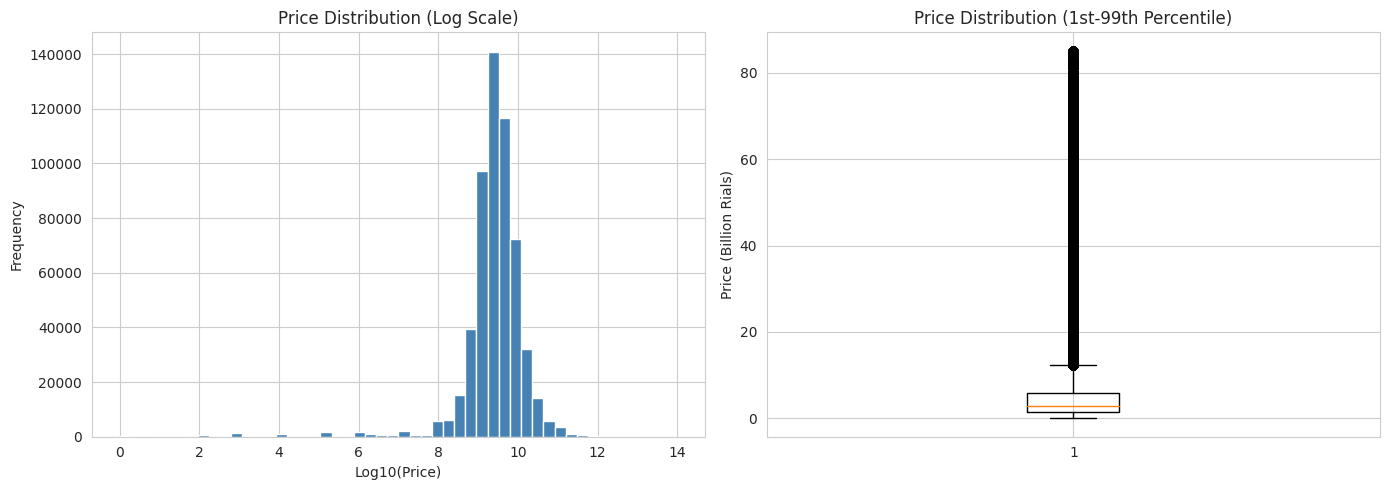

In [19]:
# Price distribution visualization
if 'price_value' in df.columns:
    price_data = pd.to_numeric(df['price_value'], errors='coerce').dropna()
    price_data = price_data[price_data > 0]  # Remove zeros
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram (log scale due to skewness)
    axes[0].hist(np.log10(price_data), bins=50, color='steelblue', edgecolor='white')
    axes[0].set_xlabel('Log10(Price)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Price Distribution (Log Scale)')
    
    # Box plot - Use only 1st to 99th percentile for better visualization
    price_trimmed = price_data[(price_data >= price_data.quantile(0.01)) & 
                               (price_data <= price_data.quantile(0.99))]
    axes[1].boxplot(price_trimmed / 1e9, vert=True)  # Convert to billions
    axes[1].set_ylabel('Price (Billion Rials)')
    axes[1].set_title('Price Distribution (1st-99th Percentile)')
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / '01_price_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

In [20]:
# Check for unrealistic prices
if 'price_value' in df.columns:
    price_data = pd.to_numeric(df['price_value'], errors='coerce').dropna()
    # Define thresholds (these may need adjustment based on Iranian Rial values)
    very_low_price = price_data[price_data < 10_000_000].count()  # Less than 10 million
    very_high_price = price_data[price_data > 500_000_000_000].count()  # More than 500 billion
    
    print(f"\nPotentially unrealistic prices:")
    print(f"  Very low (<10M): {very_low_price:,}")
    print(f"  Very high (>500B): {very_high_price:,}")


Potentially unrealistic prices:
  Very low (<10M): 12,973
  Very high (>500B): 862


### 5.3 Building Size Analysis

In [21]:
if 'building_size' in df.columns:
    size_data = pd.to_numeric(df['building_size'], errors='coerce').dropna()
    
    print("=" * 60)
    print("BUILDING SIZE ANALYSIS")
    print("=" * 60)
    print(f"Count: {len(size_data):,}")
    print(f"Min: {size_data.min():.0f} sqm")
    print(f"Max: {size_data.max():,.0f} sqm")
    print(f"Mean: {size_data.mean():.0f} sqm")
    print(f"Median: {size_data.median():.0f} sqm")
    
    # Check for unrealistic sizes
    very_small = (size_data < 10).sum()  # Less than 10 sqm
    very_large = (size_data > 10000).sum()  # More than 10,000 sqm
    
    print(f"\nPotentially unrealistic sizes:")
    print(f"  Very small (<10 sqm): {very_small:,}")
    print(f"  Very large (>10,000 sqm): {very_large:,}")

BUILDING SIZE ANALYSIS
Count: 980,394
Min: 1 sqm
Max: 10,000,000 sqm
Mean: 4441 sqm
Median: 103 sqm

Potentially unrealistic sizes:
  Very small (<10 sqm): 4,652
  Very large (>10,000 sqm): 9,428


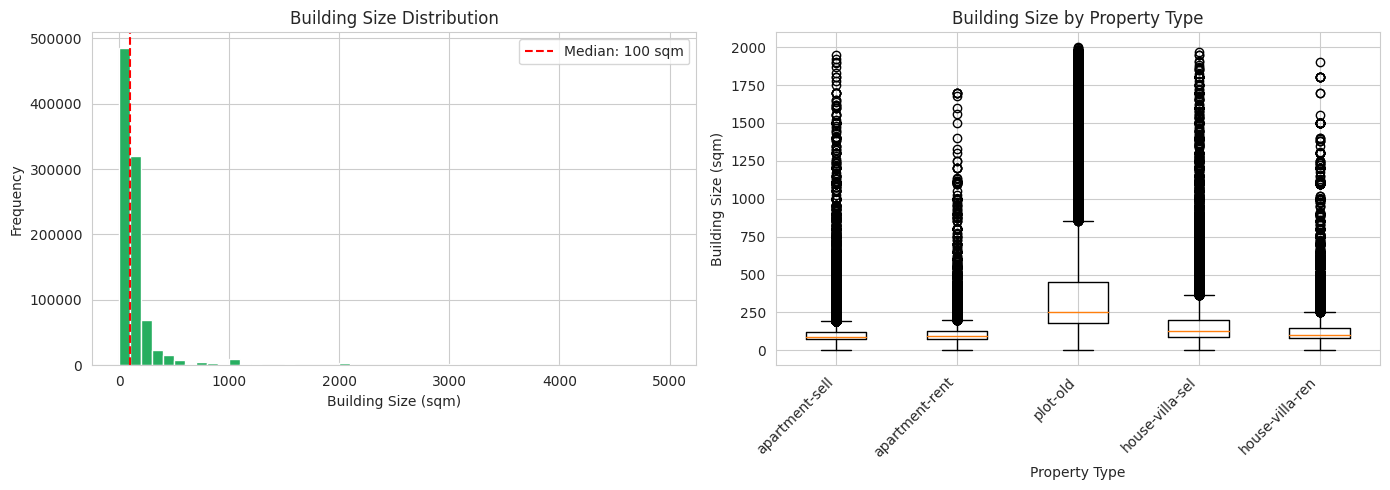

In [22]:
# Building size distribution visualization
if 'building_size' in df.columns:
    size_data = pd.to_numeric(df['building_size'], errors='coerce').dropna()
    size_data = size_data[(size_data > 0) & (size_data < 5000)]  # Reasonable range
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(size_data, bins=50, color='#27ae60', edgecolor='white')
    axes[0].set_xlabel('Building Size (sqm)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Building Size Distribution')
    axes[0].axvline(x=size_data.median(), color='red', linestyle='--', 
                    label=f'Median: {size_data.median():.0f} sqm')
    axes[0].legend()
    
    # Box plot by property type (if available)
    if 'cat3_slug' in df.columns:
        top_cats = df['cat3_slug'].value_counts().head(5).index.tolist()
        size_by_cat = [pd.to_numeric(df[df['cat3_slug'] == cat]['building_size'], 
                                     errors='coerce').dropna() for cat in top_cats]
        size_by_cat = [s[(s > 0) & (s < 2000)] for s in size_by_cat]  # Filter
        
        axes[1].boxplot(size_by_cat, labels=[c[:15] for c in top_cats])
        axes[1].set_xlabel('Property Type')
        axes[1].set_ylabel('Building Size (sqm)')
        axes[1].set_title('Building Size by Property Type')
        plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / '01_building_size_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5.4 Floor and Rooms Analysis

In [23]:
# Check floor vs total_floors consistency
if 'floor' in df.columns and 'total_floors_count' in df.columns:
    print("=" * 60)
    print("FLOOR CONSISTENCY CHECK")
    print("=" * 60)
    
    # Check unique values
    print(f"Unique floor values: {df['floor'].nunique()}")
    print(f"Floor value counts:\n{df['floor'].value_counts().head(15)}")
    
    print(f"\nUnique total_floors values: {df['total_floors_count'].nunique()}")
    print(f"Total floors value counts:\n{df['total_floors_count'].value_counts().head(15)}")

FLOOR CONSISTENCY CHECK
Unique floor values: 33
Floor value counts:
floor
2     128518
1     119565
3     109324
4      71927
5      37604
0      35855
6      13784
7       5713
-1      4464
8       3298
10      2302
9       2193
11      1474
12      1232
13       834
Name: count, dtype: int64

Unique total_floors values: 31
Total floors value counts:
total_floors_count
4     89581
5     79951
3     52795
6     28893
2     22747
7      8276
8      4588
14     3048
10     2917
9      2005
12     1783
11     1401
13     1066
15      993
16      715
Name: count, dtype: int64


ROOMS COUNT ANALYSIS
Unique values: 6
Value counts:
rooms_count
دو              404050
یک              192083
سه              138633
بدون اتاق        75898
چهار             21371
پنج یا بیشتر     13864
Name: count, dtype: int64


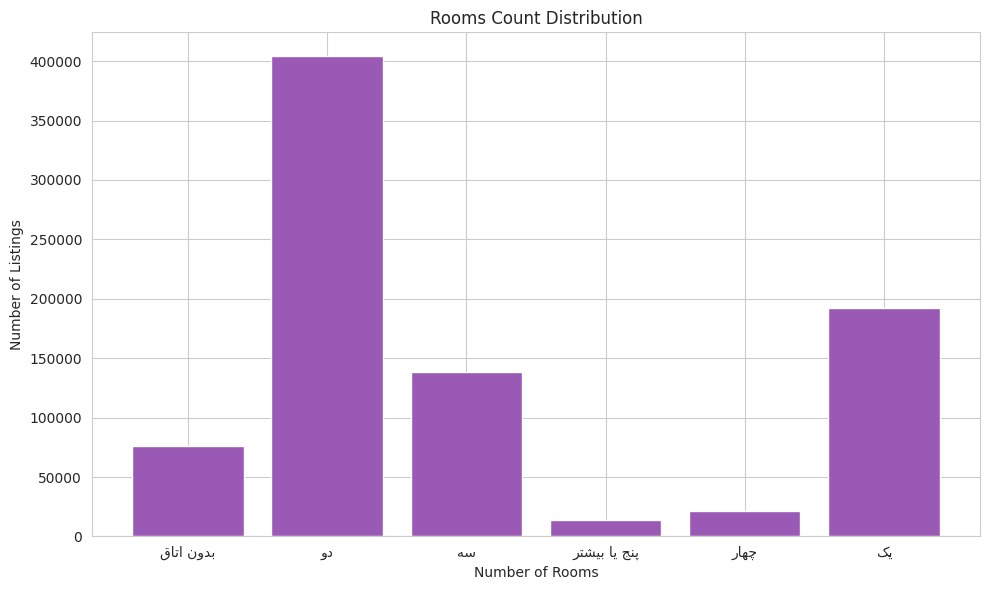

In [24]:
# Rooms count analysis and visualization with Persian text fix
if 'rooms_count' in df.columns:
    print("=" * 60)
    print("ROOMS COUNT ANALYSIS")
    print("=" * 60)
    print(f"Unique values: {df['rooms_count'].nunique()}")
    print(f"Value counts:\n{df['rooms_count'].value_counts()}")
    
    # Visualization with Persian text fix
    fig, ax = plt.subplots(figsize=(10, 6))
    rooms_counts = df['rooms_count'].value_counts().sort_index()
    
    # Fix Persian labels
    fixed_labels = [fix_persian(str(label)) for label in rooms_counts.index]
    
    ax.bar(fixed_labels, rooms_counts.values, color='#9b59b6')
    ax.set_xlabel('Number of Rooms')
    ax.set_ylabel('Number of Listings')
    ax.set_title('Rooms Count Distribution')
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / '01_rooms_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5.5 Construction Year Analysis

In [25]:
if 'construction_year' in df.columns:
    print("=" * 60)
    print("CONSTRUCTION YEAR ANALYSIS")
    print("=" * 60)
    print(f"Unique values: {df['construction_year'].nunique()}")
    print(f"Value counts:\n{df['construction_year'].value_counts().head(20)}")
    
    # Note: Persian calendar years (e.g., 1403 = 2024)

CONSTRUCTION YEAR ANALYSIS
Unique values: 34
Value counts:
construction_year
۱۴۰۳           116260
۱۳۹۰            59139
۱۴۰۲            58424
۱۴۰۰            53674
۱۳۹۵            53029
۱۳۹۸            38207
۱۳۹۷            36326
۱۳۹۶            35487
۱۴۰۱            35328
۱۳۸۵            34065
۱۳۹۹            29594
۱۳۹۳            29094
۱۳۹۲            26130
۱۳۹۴            26110
۱۳۸۸            24268
۱۳۸۰            23480
قبل از ۱۳۷۰     20637
۱۳۸۹            16755
۱۳۹۱            16316
۱۳۸۷            14136
Name: count, dtype: int64


### 5.6 Categorical Columns Analysis

In [26]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns ({len(categorical_cols)}):")
print(categorical_cols)

Categorical columns (43):
['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug', 'created_at_month', 'user_type', 'description', 'title', 'rent_mode', 'rent_to_single', 'rent_type', 'price_mode', 'credit_mode', 'rent_credit_transform', 'transformable_price', 'deed_type', 'has_business_deed', 'floor', 'rooms_count', 'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt', 'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool', 'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type', 'extra_person_capacity']


In [27]:
# Value counts for key categorical columns
key_categorical = ['cat2_slug', 'cat3_slug', 'city_slug', 'user_type']
existing_categorical = [col for col in key_categorical if col in df.columns]

for col in existing_categorical:
    print("=" * 60)
    print(f"{col.upper()}")
    print("=" * 60)
    print(f"Unique values: {df[col].nunique()}")
    print(f"Null count: {df[col].isnull().sum()}")
    print(f"\nTop 15 values:")
    print(df[col].value_counts().head(15))
    print()

CAT2_SLUG
Unique values: 6
Null count: 0

Top 15 values:
cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64

CAT3_SLUG
Unique values: 16
Null count: 1

Top 15 values:
cat3_slug
apartment-sell                        303385
apartment-rent                        211880
plot-old                              133570
house-villa-sell                      121753
house-villa-rent                       64678
shop-rent                              45993
shop-sell                              21855
office-rent                            21418
suite-apartment                        16465
presell                                15781
villa                                  12899
industry-agriculture-business-sell     11851
industry-agriculture-business-rent      9155
office-sell                             5155
partnership           

### 5.7 Geographic Data Check

In [28]:
if 'location_latitude' in df.columns and 'location_longitude' in df.columns:
    print("=" * 60)
    print("GEOGRAPHIC DATA CHECK")
    print("=" * 60)
    
    lat = pd.to_numeric(df['location_latitude'], errors='coerce').dropna()
    lon = pd.to_numeric(df['location_longitude'], errors='coerce').dropna()
    
    print(f"Latitude - Min: {lat.min():.4f}, Max: {lat.max():.4f}")
    print(f"Longitude - Min: {lon.min():.4f}, Max: {lon.max():.4f}")
    
    # Iran's approximate bounds: Lat 25-40, Lon 44-64
    outside_iran = ((lat < 25) | (lat > 40) | (lon < 44) | (lon > 64)).sum()
    print(f"\nCoordinates outside Iran bounds: {outside_iran:,}")

GEOGRAPHIC DATA CHECK
Latitude - Min: 23.6265, Max: 40.3581
Longitude - Min: 40.1624, Max: 74.5116

Coordinates outside Iran bounds: 47


## 6. Distribution Visualizations

### 6.1 City Distribution

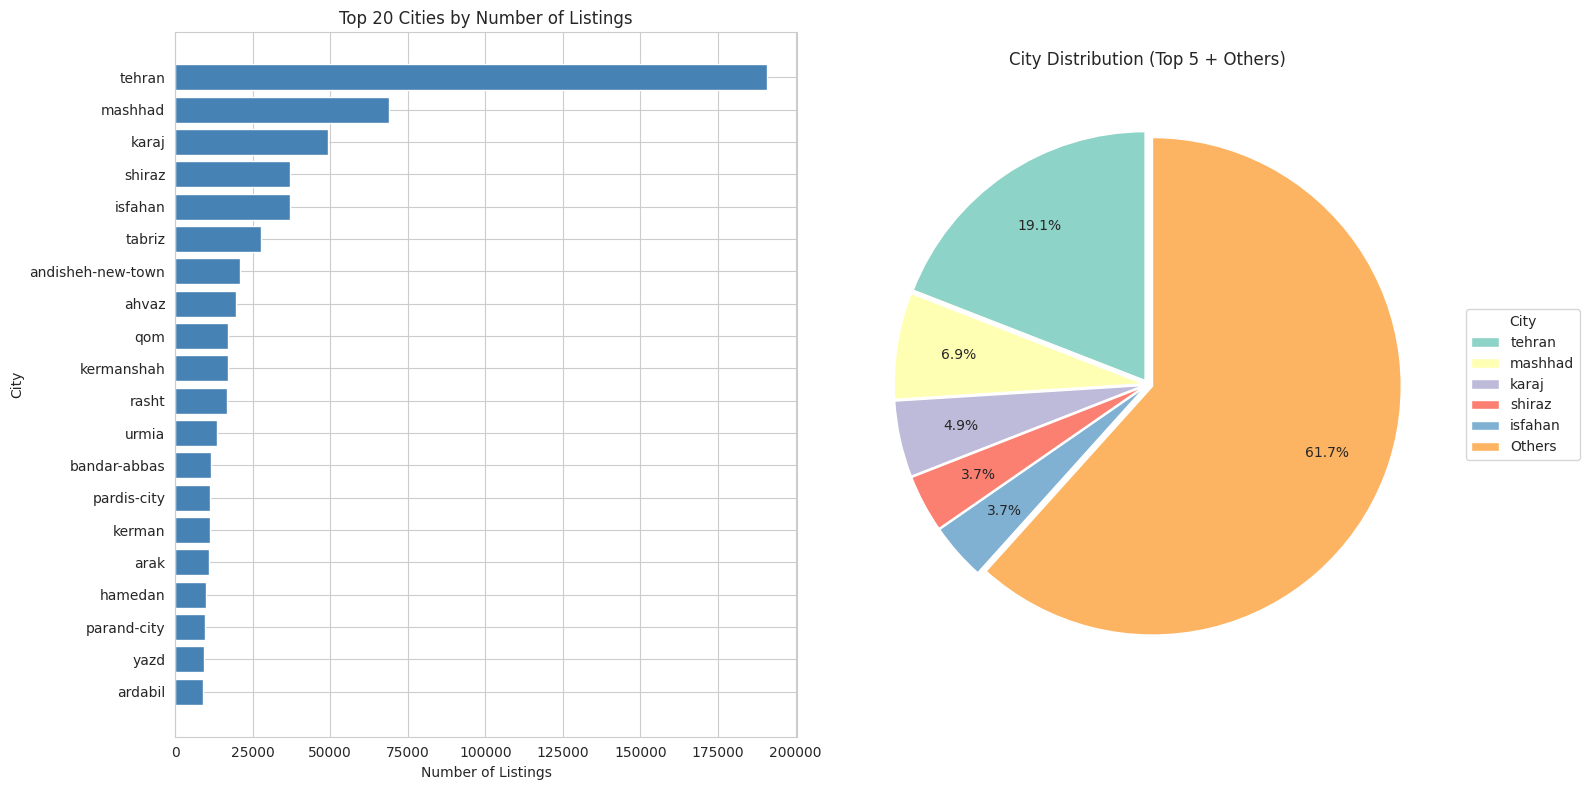


Total cities: 421
Top 5 cities cover: 38.3% of listings


In [29]:
# City distribution - Top 20 cities (Bar chart only, no overlapping pie)
if 'city_slug' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar chart - Top 20
    city_counts = df['city_slug'].value_counts().head(20)
    axes[0].barh(city_counts.index[::-1], city_counts.values[::-1], color='steelblue')
    axes[0].set_xlabel('Number of Listings')
    axes[0].set_ylabel('City')
    axes[0].set_title('Top 20 Cities by Number of Listings')
    
    # Pie chart - Top 5 + Others (fewer slices to avoid overlap)
    city_top5 = df['city_slug'].value_counts().head(5)
    others = df['city_slug'].value_counts()[5:].sum()
    city_pie = pd.concat([city_top5, pd.Series({'Others': others})])
    
    # Use explode to separate slices
    explode = [0.02] * len(city_pie)
    colors = plt.cm.Set3(range(len(city_pie)))
    
    wedges, texts, autotexts = axes[1].pie(
        city_pie.values, 
        labels=None,  # No labels on pie, use legend
        autopct='%1.1f%%',
        startangle=90, 
        explode=explode,
        colors=colors,
        pctdistance=0.75
    )
    
    # Add legend instead of labels
    axes[1].legend(wedges, city_pie.index, title='City', loc='center left', 
                   bbox_to_anchor=(1, 0.5), fontsize=10)
    axes[1].set_title('City Distribution (Top 5 + Others)')
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / '01_city_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nTotal cities: {df['city_slug'].nunique()}")
    print(f"Top 5 cities cover: {city_top5.sum() / len(df) * 100:.1f}% of listings")

### 6.2 Property Type Distribution

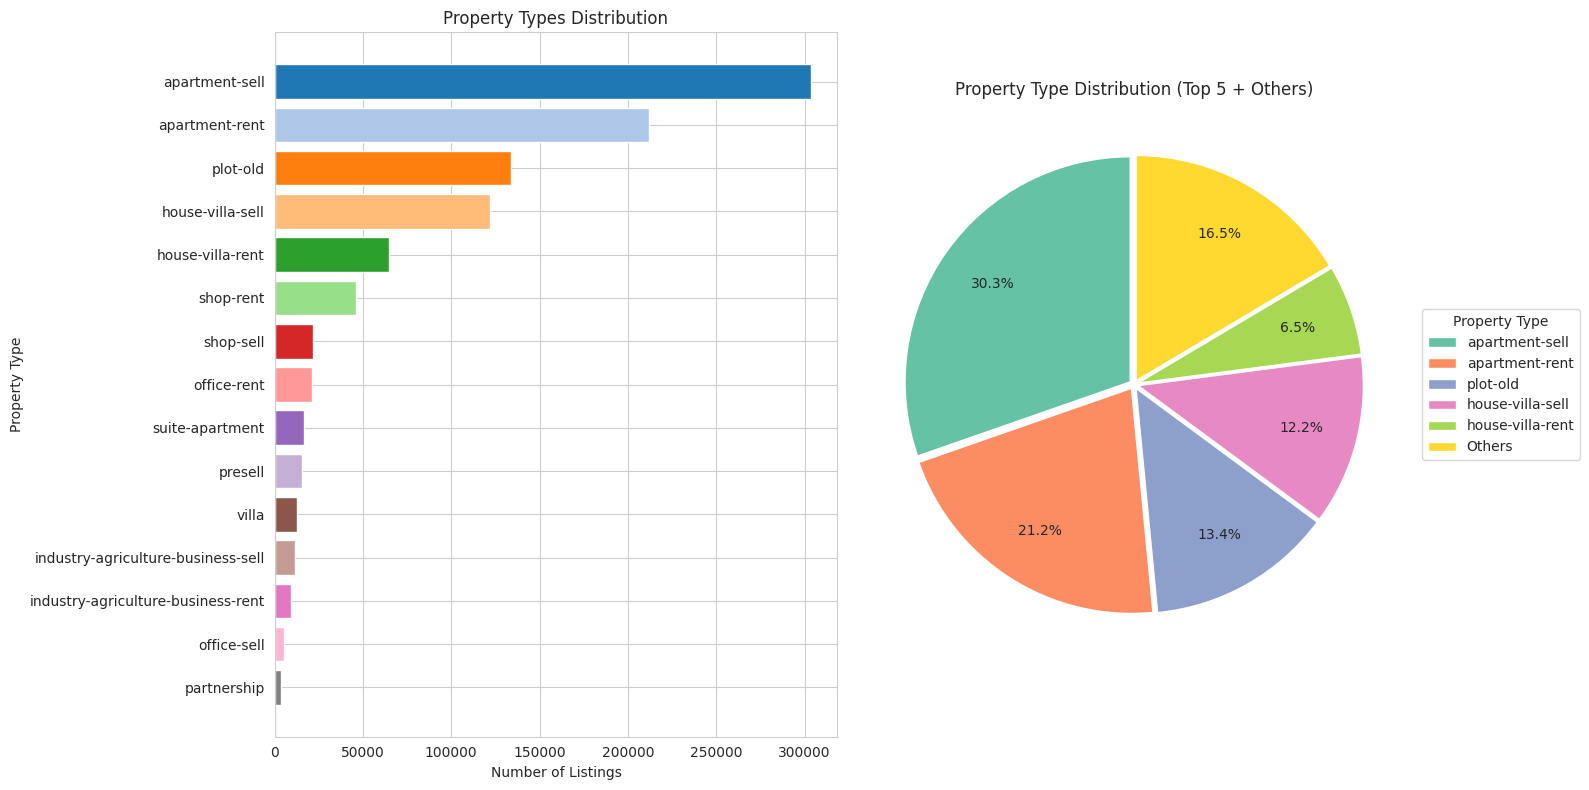

In [30]:
# Property type distribution - Fixed visualization
if 'cat3_slug' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar chart - All property types
    cat3_counts = df['cat3_slug'].value_counts().head(15)
    colors = plt.cm.tab20(range(len(cat3_counts)))
    axes[0].barh(cat3_counts.index[::-1], cat3_counts.values[::-1], color=colors[::-1])
    axes[0].set_xlabel('Number of Listings')
    axes[0].set_ylabel('Property Type')
    axes[0].set_title('Property Types Distribution')
    
    # Pie chart - Top 5 + Others (fewer slices)
    cat3_top = df['cat3_slug'].value_counts().head(5)
    others = df['cat3_slug'].value_counts()[5:].sum()
    cat3_pie = pd.concat([cat3_top, pd.Series({'Others': others})])
    
    explode = [0.02] * len(cat3_pie)
    colors = plt.cm.Set2(range(len(cat3_pie)))
    
    wedges, texts, autotexts = axes[1].pie(
        cat3_pie.values, 
        labels=None,
        autopct='%1.1f%%', 
        startangle=90,
        explode=explode,
        colors=colors,
        pctdistance=0.75
    )
    
    axes[1].legend(wedges, cat3_pie.index, title='Property Type', loc='center left',
                   bbox_to_anchor=(1, 0.5), fontsize=10)
    axes[1].set_title('Property Type Distribution (Top 5 + Others)')
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / '01_property_type_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

### 6.3 Category Distribution (Sell vs Rent)

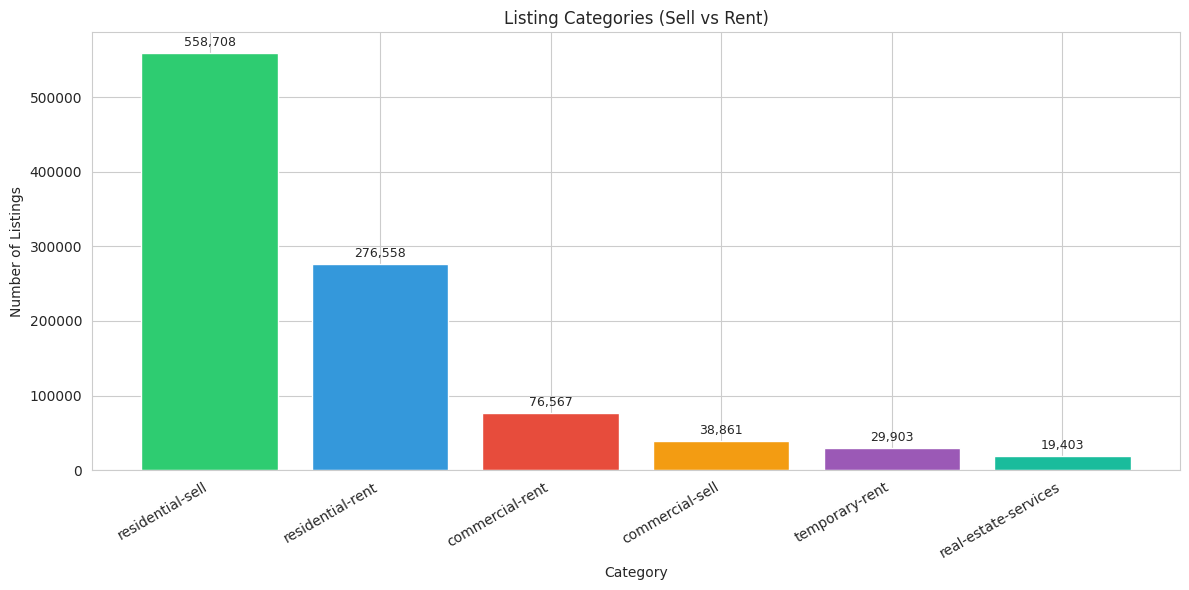

In [31]:
if 'cat2_slug' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    cat2_counts = df['cat2_slug'].value_counts()
    colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c'][:len(cat2_counts)]
    
    bars = ax.bar(range(len(cat2_counts)), cat2_counts.values, color=colors)
    ax.set_xlabel('Category')
    ax.set_ylabel('Number of Listings')
    ax.set_title('Listing Categories (Sell vs Rent)')
    ax.set_xticks(range(len(cat2_counts)))
    ax.set_xticklabels(cat2_counts.index, rotation=30, ha='right')
    
    # Add value labels on bars
    for bar, val in zip(bars, cat2_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
                f'{val:,}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / '01_category_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

### 6.4 Time Distribution (by Month)

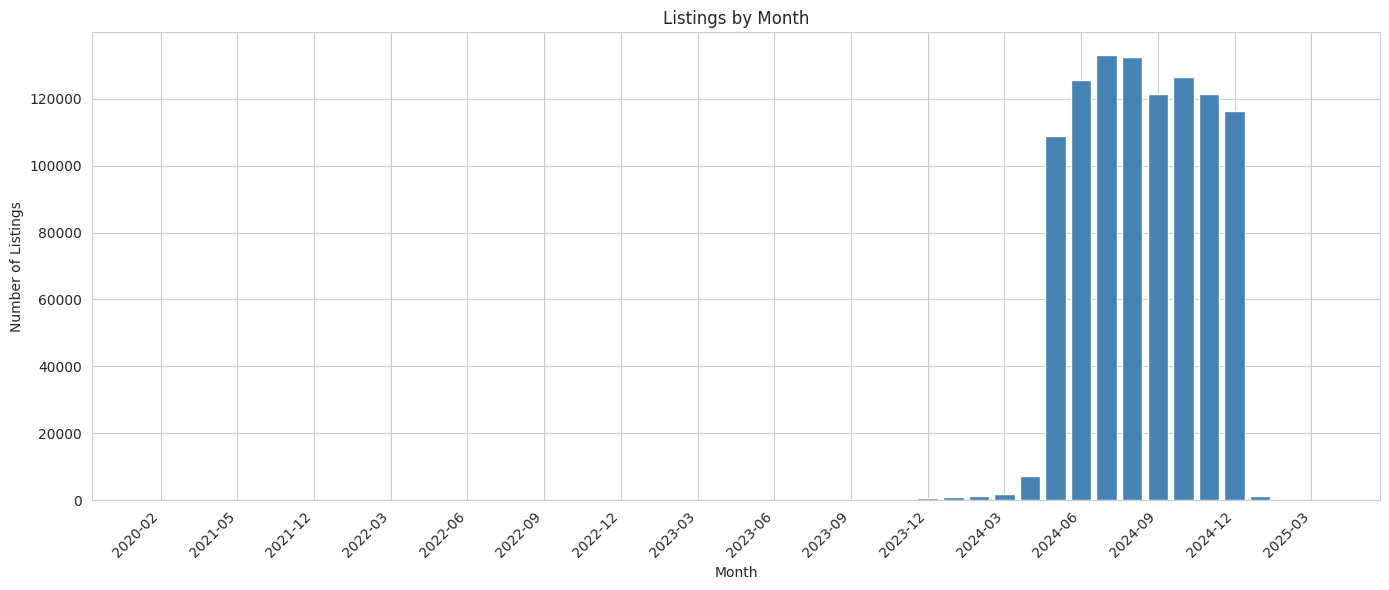

Data spans 46 months
Date range: 2020-02-01 00:00:00 to 2025-03-01 00:00:00


In [32]:
# Time distribution - Fixed with better x-axis labels
if 'created_at_month' in df.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Get month counts and sort
    month_counts = df['created_at_month'].value_counts().sort_index()
    
    # Create shorter labels (YYYY-MM format)
    x_labels = [str(m)[:7] if len(str(m)) > 7 else str(m) for m in month_counts.index]
    
    ax.bar(range(len(month_counts)), month_counts.values, color='steelblue')
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of Listings')
    ax.set_title('Listings by Month')
    
    # Show only every Nth label to avoid crowding
    n_labels = len(x_labels)
    step = max(1, n_labels // 12)  # Show ~12 labels max
    ax.set_xticks(range(0, n_labels, step))
    ax.set_xticklabels([x_labels[i] for i in range(0, n_labels, step)], rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / '01_time_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Data spans {df['created_at_month'].nunique()} months")
    print(f"Date range: {month_counts.index.min()} to {month_counts.index.max()}")

### 6.5 User Type Distribution

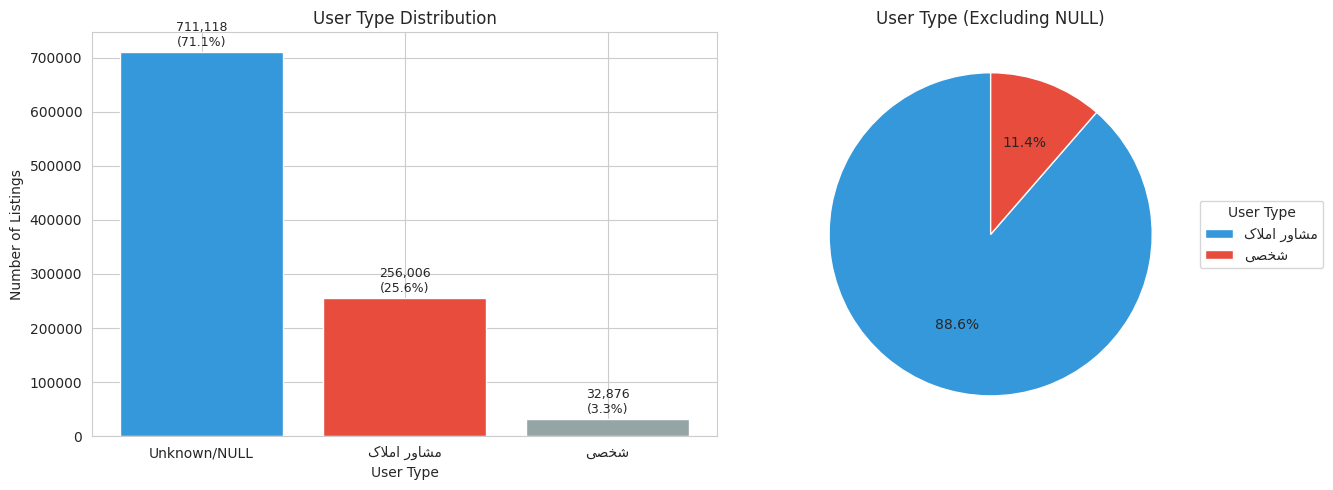

In [33]:
# User type distribution with Persian text fix - Improved layout
if 'user_type' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Value counts including NaN
    user_counts = df['user_type'].value_counts(dropna=False)
    
    # Fix Persian labels
    user_labels = [fix_persian(str(idx)) if pd.notna(idx) else 'Unknown/NULL' 
                   for idx in user_counts.index]
    
    # Bar chart
    colors = ['#3498db', '#e74c3c', '#95a5a6'][:len(user_counts)]
    bars = axes[0].bar(range(len(user_counts)), user_counts.values, color=colors)
    axes[0].set_xlabel('User Type')
    axes[0].set_ylabel('Number of Listings')
    axes[0].set_title('User Type Distribution')
    axes[0].set_xticks(range(len(user_counts)))
    axes[0].set_xticklabels(user_labels)
    
    # Add value labels
    for i, val in enumerate(user_counts.values):
        axes[0].text(i, val + 5000, f'{val:,}\n({val/len(df)*100:.1f}%)', 
                    ha='center', va='bottom', fontsize=9)
    
    # Pie chart (without NULL) - with legend
    user_valid = df['user_type'].value_counts(dropna=True)
    user_valid_labels = [fix_persian(str(idx)) for idx in user_valid.index]
    
    wedges, texts, autotexts = axes[1].pie(
        user_valid.values, 
        labels=None,
        autopct='%1.1f%%',
        colors=['#3498db', '#e74c3c'], 
        startangle=90,
        pctdistance=0.6
    )
    axes[1].legend(wedges, user_valid_labels, title='User Type', loc='center left',
                   bbox_to_anchor=(1, 0.5))
    axes[1].set_title('User Type (Excluding NULL)')
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / '01_user_type_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Summary and Recommendations

In [34]:
print("=" * 70)
print("DATA QUALITY SUMMARY")
print("=" * 70)

print(f"""
DATASET STATISTICS:
- Total records: {len(df):,}
- Total columns: {len(df.columns)}
- Duplicate rows: {duplicate_count:,} ({duplicate_percent:.2f}%)

COLUMN AVAILABILITY:
- High availability (<=5% missing): {len(high_availability)} columns
- Medium availability (5-50% missing): {len(medium_availability)} columns
- Low availability (>50% missing): {len(low_availability)} columns

COLUMNS RECOMMENDED FOR EXCLUSION (>50% missing):
{low_availability}

COLUMNS SAFE FOR CORE ANALYSIS:
{high_availability}
""")

DATA QUALITY SUMMARY

DATASET STATISTICS:
- Total records: 1,000,000
- Total columns: 60
- Duplicate rows: 0 (0.00%)

COLUMN AVAILABILITY:
- High availability (<=5% missing): 7 columns
- Medium availability (5-50% missing): 12 columns
- Low availability (>50% missing): 41 columns

COLUMNS RECOMMENDED FOR EXCLUSION (>50% missing):
['rent_to_single', 'cost_per_extra_person', 'rent_price_on_special_days', 'rent_price_at_weekends', 'rent_price_on_regular_days', 'extra_person_capacity', 'property_type', 'has_sauna', 'has_jacuzzi', 'has_pool', 'regular_person_capacity', 'has_barbecue', 'has_security_guard', 'has_gas', 'has_water', 'has_electricity', 'has_business_deed', 'transformed_credit', 'transformed_rent', 'rent_type', 'land_size', 'deed_type', 'user_type', 'unit_per_floor', 'total_floors_count', 'building_direction', 'location_radius', 'has_cooling_system', 'transformable_rent', 'rent_value', 'transformable_credit', 'credit_value', 'transformable_price', 'rent_credit_transform', 'credi

In [35]:
# Create a quality summary dataframe
quality_summary = missing_stats.copy()
quality_summary['availability_category'] = pd.cut(
    quality_summary['missing_percent'],
    bins=[-1, 5, 50, 100],
    labels=['High', 'Medium', 'Low']
)

# Save quality summary
quality_summary.to_csv(DATA_PROCESSED / 'column_quality_summary.csv', index=False)
print(f"Quality summary saved to: {DATA_PROCESSED / 'column_quality_summary.csv'}")

Quality summary saved to: /home/bahman/b/repositories/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar/data/processed/column_quality_summary.csv


In [36]:
# Create summary statistics table
summary_data = {
    'Metric': [
        'Total Records',
        'Total Columns',
        'Duplicate Rows',
        'High Availability Columns (<=5% missing)',
        'Medium Availability Columns (5-50% missing)',
        'Low Availability Columns (>50% missing)',
        'Unique Cities',
        'Unique Property Types',
        'Date Range'
    ],
    'Value': [
        f"{len(df):,}",
        f"{len(df.columns)}",
        f"{duplicate_count:,} ({duplicate_percent:.2f}%)",
        f"{len(high_availability)}",
        f"{len(medium_availability)}",
        f"{len(low_availability)}",
        f"{df['city_slug'].nunique() if 'city_slug' in df.columns else 'N/A'}",
        f"{df['cat3_slug'].nunique() if 'cat3_slug' in df.columns else 'N/A'}",
        f"{df['created_at_month'].min()} to {df['created_at_month'].max()}" if 'created_at_month' in df.columns else 'N/A'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv(DATA_PROCESSED / 'data_quality_summary.csv', index=False)
print(f"\nSummary saved to: {DATA_PROCESSED / 'data_quality_summary.csv'}")

FINAL SUMMARY
                                     Metric                                      Value
                              Total Records                                  1,000,000
                              Total Columns                                         60
                             Duplicate Rows                                  0 (0.00%)
   High Availability Columns (<=5% missing)                                          7
Medium Availability Columns (5-50% missing)                                         12
    Low Availability Columns (>50% missing)                                         41
                              Unique Cities                                        421
                      Unique Property Types                                         16
                                 Date Range 2020-02-01 00:00:00 to 2025-03-01 00:00:00

Summary saved to: /home/bahman/b/repositories/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar/da

## 8. Data Cleaning and Preparation

Based on the quality assessment, we perform comprehensive data cleaning to prepare a solid foundation for subsequent analysis phases.

### Cleaning Steps:
1. Remove exact duplicates
2. Convert numeric columns stored as objects to proper numeric types
3. Handle outliers in price and building size
4. Create separate datasets for different analysis needs

In [37]:
# Start with a copy of the original data
df_cleaned = df.copy()
print(f"Starting with {len(df_cleaned):,} rows")

# Step 1: Remove exact duplicates
initial_rows = len(df_cleaned)
df_cleaned = df_cleaned.drop_duplicates()
removed_duplicates = initial_rows - len(df_cleaned)
print(f"Step 1 - Removed {removed_duplicates:,} exact duplicate rows")

Starting with 1,000,000 rows
Step 1 - Removed 0 exact duplicate rows


In [38]:
# Step 2: Convert numeric columns that are stored as object type
numeric_conversion_cols = ['price_value', 'rent_value', 'credit_value', 
                           'building_size', 'land_size', 'location_latitude', 
                           'location_longitude', 'location_radius']

print("\nStep 2 - Converting numeric columns:")
for col in numeric_conversion_cols:
    if col in df_cleaned.columns:
        original_dtype = df_cleaned[col].dtype
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')
        print(f"  {col}: {original_dtype} -> {df_cleaned[col].dtype}")


Step 2 - Converting numeric columns:
  price_value: float64 -> float64
  rent_value: float64 -> float64
  credit_value: float64 -> float64
  building_size: float64 -> float64
  land_size: float64 -> float64
  location_latitude: float64 -> float64
  location_longitude: float64 -> float64
  location_radius: float64 -> float64


In [39]:
# Step 3: Create outlier flags (don't remove, just flag for analysis flexibility)
print("\nStep 3 - Creating outlier flags:")

# Price outlier flags (for records with price)
if 'price_value' in df_cleaned.columns:
    price_valid = df_cleaned['price_value'].notna() & (df_cleaned['price_value'] > 0)
    price_q01 = df_cleaned.loc[price_valid, 'price_value'].quantile(0.01)
    price_q99 = df_cleaned.loc[price_valid, 'price_value'].quantile(0.99)
    
    df_cleaned['price_outlier'] = (
        (df_cleaned['price_value'] < price_q01) | 
        (df_cleaned['price_value'] > price_q99)
    ).fillna(False)
    
    print(f"  Price outliers flagged: {df_cleaned['price_outlier'].sum():,} rows")
    print(f"    Valid price range (1st-99th percentile): {price_q01:,.0f} - {price_q99:,.0f}")

# Building size outlier flags
if 'building_size' in df_cleaned.columns:
    size_valid = df_cleaned['building_size'].notna() & (df_cleaned['building_size'] > 0)
    size_q01 = df_cleaned.loc[size_valid, 'building_size'].quantile(0.01)
    size_q99 = df_cleaned.loc[size_valid, 'building_size'].quantile(0.99)
    
    df_cleaned['size_outlier'] = (
        (df_cleaned['building_size'] < size_q01) | 
        (df_cleaned['building_size'] > size_q99)
    ).fillna(False)
    
    print(f"  Size outliers flagged: {df_cleaned['size_outlier'].sum():,} rows")
    print(f"    Valid size range (1st-99th percentile): {size_q01:.0f} - {size_q99:.0f} sqm")


Step 3 - Creating outlier flags:
  Price outliers flagged: 12,728 rows
    Valid price range (1st-99th percentile): 111,111 - 85,157,000,000
  Size outliers flagged: 16,435 rows
    Valid size range (1st-99th percentile): 12 - 10000 sqm


In [40]:
# Step 4: Create a 'listing_type' column for easier filtering (sell vs rent)
print("\nStep 4 - Creating listing type categories:")

if 'cat2_slug' in df_cleaned.columns:
    def categorize_listing(cat2):
        if pd.isna(cat2):
            return 'unknown'
        cat2_lower = str(cat2).lower()
        if 'sell' in cat2_lower:
            return 'sell'
        elif 'rent' in cat2_lower:
            return 'rent'
        else:
            return 'other'
    
    df_cleaned['listing_type'] = df_cleaned['cat2_slug'].apply(categorize_listing)
    print(f"  Listing types: {df_cleaned['listing_type'].value_counts().to_dict()}")


Step 4 - Creating listing type categories:
  Listing types: {'sell': 597569, 'rent': 383028, 'other': 19403}


In [41]:
# Step 5: Create data quality score for each row
print("\nStep 5 - Creating row quality scores:")

# Key columns for quality scoring
key_columns_for_quality = ['title', 'city_slug', 'cat3_slug', 'building_size', 
                           'price_value', 'rooms_count', 'description']
existing_key_cols = [col for col in key_columns_for_quality if col in df_cleaned.columns]

# Calculate completeness score (percentage of key columns that are not null)
df_cleaned['quality_score'] = df_cleaned[existing_key_cols].notna().sum(axis=1) / len(existing_key_cols) * 100

print(f"  Quality score distribution:")
print(f"    Mean: {df_cleaned['quality_score'].mean():.1f}%")
print(f"    Median: {df_cleaned['quality_score'].median():.1f}%")
print(f"    Min: {df_cleaned['quality_score'].min():.1f}%")
print(f"    Max: {df_cleaned['quality_score'].max():.1f}%")


Step 5 - Creating row quality scores:
  Quality score distribution:
    Mean: 91.4%
    Median: 85.7%
    Min: 42.9%
    Max: 100.0%


In [42]:
# Final summary of cleaned data
print("\n" + "=" * 70)
print("CLEANED DATA SUMMARY")
print("=" * 70)
print(f"Total rows: {len(df_cleaned):,}")
print(f"Total columns: {len(df_cleaned.columns)} (added: price_outlier, size_outlier, listing_type, quality_score)")

# Count records with valid price for price prediction (Phase 5)
valid_price_count = df_cleaned['price_value'].notna().sum()
print(f"\nRecords with valid price: {valid_price_count:,} ({valid_price_count/len(df_cleaned)*100:.1f}%)")

# Count by listing type
print(f"\nBy listing type:")
for lt in df_cleaned['listing_type'].unique():
    count = (df_cleaned['listing_type'] == lt).sum()
    print(f"  {lt}: {count:,} ({count/len(df_cleaned)*100:.1f}%)")


CLEANED DATA SUMMARY
Total rows: 1,000,000
Total columns: 64 (added: price_outlier, size_outlier, listing_type, quality_score)

Records with valid price: 568,346 (56.8%)

By listing type:
  rent: 383,028 (38.3%)
  sell: 597,569 (59.8%)
  other: 19,403 (1.9%)


In [ ]:
# Save the cleaned dataset
df_cleaned.to_csv(DATA_PROCESSED / 'cleaned_data.csv', index=False)
print(f"\nCleaned data saved to: {DATA_PROCESSED / 'cleaned_data.csv'}")
print(f"File size: {(DATA_PROCESSED / 'cleaned_data.csv').stat().st_size / 1024**2:.1f} MB")

In [ ]:
# Create a subset for price prediction (Phase 5) - only records with valid prices
df_for_price_prediction = df_cleaned[
    (df_cleaned['price_value'].notna()) & 
    (df_cleaned['price_value'] > 0) &
    (df_cleaned['listing_type'] == 'sell') &
    (~df_cleaned['price_outlier'])
].copy()

print("\nPrice Prediction Dataset (Phase 5):")
print(f"  Rows: {len(df_for_price_prediction):,}")
print(f"  This represents {len(df_for_price_prediction)/len(df_cleaned)*100:.1f}% of cleaned data")

df_for_price_prediction.to_csv(DATA_PROCESSED / 'data_for_price_prediction.csv', index=False)
print(f"  Saved to: {DATA_PROCESSED / 'data_for_price_prediction.csv'}")

In [ ]:
# Create a subset for rental analysis
df_rentals = df_cleaned[
    (df_cleaned['listing_type'] == 'rent')
].copy()

print("\nRental Analysis Dataset:")
print(f"  Rows: {len(df_rentals):,}")

df_rentals.to_csv(DATA_PROCESSED / 'data_rentals.csv', index=False)
print(f"  Saved to: {DATA_PROCESSED / 'data_rentals.csv'}")

## 9. Next Steps

The data quality assessment and cleaning is complete. 

### Key Findings:
1. **Missing Values**: 41 columns have >50% missing data - these will be used sparingly
2. **Duplicates**: No exact duplicates found
3. **Data Types**: Converted numeric columns from object to proper numeric types
4. **Outliers**: Flagged price and size outliers for flexible filtering

### Datasets Created:
1. **cleaned_data.csv**: Full cleaned dataset with all records
2. **data_for_price_prediction.csv**: Filtered for Phase 5 (valid sell prices, no outliers)
3. **data_rentals.csv**: Rental listings for rental market analysis

### Column Quality Summary:
- **column_quality_summary.csv**: Detailed missing value statistics per column
- **data_quality_summary.csv**: Overall dataset summary metrics

Proceed to **Phase 2: Exploratory Data Analysis** with the cleaned dataset.